# Análisis de Rentabilidad y Desempeño Financiero

## Objetivo

Analizar el comportamiento de los ingresos, costos y rentabilidad de una empresa comercial, identificando patrones y diferencias relevantes por período, producto, categoría, región y segmento de clientes.

## Preguntas de negocio

1. ¿Cómo evolucionan los ingresos a través del tiempo?
2. ¿Cómo se comportan los costos?
3. ¿Cómo evoluciona la rentabilidad?
4. ¿Qué productos o categorías tienen mayor contribución?
5. ¿Existen diferencias entre regiones?
6. ¿Qué segmentos de clientes presentan diferencias relevantes?
7. ¿Qué hallazgos pueden apoyar decisiones comerciales y financieras?


In [80]:
import pandas as pd

df = pd.read_csv("../data/superstore.csv")

In [81]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [82]:
df.shape

(10800, 21)

In [83]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

In [85]:
df.isna().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [86]:
df.duplicated().sum()

np.int64(504)

In [87]:
df.dtypes

Row ID               str
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

In [88]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Revisión de calidad de los datos

La exploración inicial del dataset muestra 10.800 registros y 21 columnas.

Se identificaron 806 registros con valores nulos en la mayoría de las variables de negocio y 817 valores nulos en Postal Code.

También se identificaron 504 registros duplicados.

Antes de realizar la limpieza, se analizará la naturaleza de estos registros para determinar si corresponden a filas vacías, duplicados reales u otras inconsistencias.

In [89]:
df[df["Sales"].isna()].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
df[df["Sales"].isna()].tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10795,Yes,US-2018-147886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10796,Yes,US-2018-147998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10797,Yes,US-2018-151127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10798,Yes,US-2018-155999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10799,Yes,US-2018-155999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
df[df["Sales"].isna()].shape

(806, 21)

In [92]:
df[df["Sales"].isna()].notna().sum()

Row ID           806
Order ID         806
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [93]:
df[df["Sales"].isna()].isna().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      806
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [94]:
df[df.duplicated(keep=False)].sort_values("Order ID").head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10000,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10001,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10002,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10006,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10008,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10010,Yes,CA-2015-103744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10011,Yes,CA-2015-103744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
df[df.duplicated(keep=False)].shape

(710, 21)

In [96]:
df.dropna(subset=["Sales"]).duplicated().sum()

np.int64(0)

In [97]:
df["Row ID"].duplicated().sum()

np.int64(799)

In [98]:
df["Row ID"].nunique()

10001

In [99]:
df["Order ID"].nunique()

5015

In [100]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

In [101]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [102]:
df["Order Date"].isna().sum()

np.int64(806)

In [103]:
df["Ship Date"].isna().sum()

np.int64(806)

In [104]:
df_clean = df.dropna(subset=["Sales"]).copy()

In [105]:
df_clean.shape

(9994, 21)

In [106]:
df_clean.duplicated().sum()

np.int64(0)

In [107]:
df[df["Sales"].isna()].shape

(806, 21)

In [108]:
df[df["Sales"].isna()].notna().sum()

Row ID           806
Order ID         806
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [109]:
df.dropna(subset=["Sales"]).duplicated().sum()

np.int64(0)

In [110]:
df["Row ID"].duplicated().sum()

np.int64(799)

In [111]:
df["Row ID"].nunique()

10001

In [112]:
df["Order ID"].nunique()

5015

In [113]:
df[df.duplicated(keep=False)].sort_values("Order ID").head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10000,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10001,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10002,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10006,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10008,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10010,Yes,CA-2015-103744,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10011,Yes,CA-2015-103744,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
df[df["Sales"].isna()][["Row ID", "Order ID", "Order Date", "Profit"]].head(20)

,Row ID,Order ID,Order Date,Profit
9994,Person,Region,NaT,NaN
9995,Anna Andreadi,West,NaT,NaN
9996,Chuck Magee,East,NaT,NaN
9997,Kelly Williams,Central,NaT,NaN
9998,Cassandra Brandow,South,NaT,NaN
9999,Returned,Order ID,NaT,NaN
10000,Yes,CA-2015-100762,NaT,NaN
10001,Yes,CA-2015-100762,NaT,NaN
10002,Yes,CA-2015-100762,NaT,NaN
10003,Yes,CA-2015-100762,NaT,NaN


In [115]:
df[df["Sales"].isna()]["Row ID"].value_counts().head(20)

Row ID
Yes                  800
Person                 1
Anna Andreadi          1
Chuck Magee            1
Kelly Williams         1
Cassandra Brandow      1
Returned               1
Name: count, dtype: int64

In [116]:
df[df["Sales"].isna()][["Row ID", "Order ID", "Customer Name", "Product Name"]].head(20)

,Row ID,Order ID,Customer Name,Product Name
9994,Person,Region,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN
9996,Chuck Magee,East,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN
9999,Returned,Order ID,NaN,NaN
10000,Yes,CA-2015-100762,NaN,NaN
10001,Yes,CA-2015-100762,NaN,NaN
10002,Yes,CA-2015-100762,NaN,NaN
10003,Yes,CA-2015-100762,NaN,NaN


In [117]:
df[df["Sales"].isna()].tail(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10780,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10781,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10782,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10783,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10784,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10785,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10786,Yes,US-2018-123834,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10787,Yes,US-2018-136679,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10788,Yes,US-2018-136679,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10789,Yes,US-2018-147886,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
df_clean = df.dropna(subset=["Sales"]).copy()

In [119]:
df_clean.shape

(9994, 21)

## Nuestra limpieza

Se excluyeron 806 registros sin información de ventas ni datos completos de negocio. Los 9.994 registros restantes no presentan duplicados exactos, por lo que no fue necesario aplicar una eliminación adicional de duplicados.

In [120]:
df_clean.shape

(9994, 21)

In [121]:
df_clean.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [122]:
df_clean.duplicated().sum()

np.int64(0)

In [123]:
df_clean[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [124]:
df_clean[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [125]:
df_clean[["Order Date", "Ship Date"]].isna().sum()

Order Date    0
Ship Date     0
dtype: int64

In [126]:
df_clean["Order Date"].min(), df_clean["Order Date"].max()

(Timestamp('2015-01-03 00:00:00'), Timestamp('2018-12-30 00:00:00'))

In [127]:
df_clean["Cost"] = df_clean["Sales"] - df_clean["Profit"]

In [128]:
df_clean["Profit Margin"] = df_clean["Profit"] / df_clean["Sales"]

In [129]:
df_clean[["Sales", "Cost", "Profit", "Profit Margin"]].head(10)

,Sales,Cost,Profit,Profit Margin
0,261.9600,220.0464,41.9136,0.1600
1,731.9400,512.3580,219.5820,0.3000
2,14.6200,7.7486,6.8714,0.4700
3,957.5775,1340.6085,-383.0310,-0.4000
4,22.3680,19.8516,2.5164,0.1125
5,48.8600,34.6906,14.1694,0.2900
6,7.2800,5.3144,1.9656,0.2700
7,907.1520,816.4368,90.7152,0.1000
8,18.5040,12.7215,5.7825,0.3125
9,114.9000,80.4300,34.4700,0.3000


In [130]:
(df_clean["Sales"] - df_clean["Profit"] - df_clean["Cost"]).abs().max()

np.float64(0.0)

In [131]:
df_clean["Profit Margin"].describe()

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [132]:
df_clean["Profit"].sum() / df_clean["Sales"].sum()

np.float64(0.12467217240315605)

In [133]:
df_clean["Cost"] = df_clean["Sales"] - df_clean["Profit"]

In [134]:
df_clean["Profit Margin"] = df_clean["Profit"] / df_clean["Sales"]

In [135]:
df_clean[["Sales", "Cost", "Profit", "Profit Margin"]].head(10)

,Sales,Cost,Profit,Profit Margin
0,261.9600,220.0464,41.9136,0.1600
1,731.9400,512.3580,219.5820,0.3000
2,14.6200,7.7486,6.8714,0.4700
3,957.5775,1340.6085,-383.0310,-0.4000
4,22.3680,19.8516,2.5164,0.1125
5,48.8600,34.6906,14.1694,0.2900
6,7.2800,5.3144,1.9656,0.2700
7,907.1520,816.4368,90.7152,0.1000
8,18.5040,12.7215,5.7825,0.3125
9,114.9000,80.4300,34.4700,0.3000


In [136]:
(df_clean["Sales"] - df_clean["Profit"] - df_clean["Cost"]).abs().max()

np.float64(0.0)

In [137]:
(df_clean["Sales"] - df_clean["Profit"] - df_clean["Cost"]).abs().max()

np.float64(0.0)

In [138]:
df_clean["Profit Margin"].describe()

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [139]:
df_clean["Profit"].sum() / df_clean["Sales"].sum()

np.float64(0.12467217240315605)

In [140]:
total_sales = df_clean["Sales"].sum()
total_cost = df_clean["Cost"].sum()
total_profit = df_clean["Profit"].sum()
total_margin = total_profit / total_sales

total_sales, total_cost, total_profit, total_margin

(np.float64(2297200.8603),
 np.float64(2010803.8386000001),
 np.float64(286397.0217),
 np.float64(0.12467217240315605))

In [141]:
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M")

In [142]:
monthly_financials = (
    df_clean
    .groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

In [143]:
monthly_financials["Profit Margin"] = (
    monthly_financials["Profit"] / monthly_financials["Sales"]
)

In [144]:
monthly_financials.head(10)

,Year-Month,Sales,Cost,Profit,Profit Margin
0,2015-01,14236.8950,11786.7043,2450.1907,0.172101
1,2015-02,4519.8920,3657.5836,862.3084,0.190781
2,2015-03,55691.0090,55192.2791,498.7299,0.008955
3,2015-04,28295.3450,24806.5098,3488.8352,0.123301
4,2015-05,23648.2870,20909.5774,2738.7096,0.115810
5,2015-06,34595.1276,29618.6032,4976.5244,0.143850
6,2015-07,33946.3930,34787.8756,-841.4826,-0.024789
7,2015-08,27909.4685,22591.3635,5318.1050,0.190548
8,2015-09,81777.3508,73449.2514,8328.0994,0.101839
9,2015-10,31453.3930,28005.1357,3448.2573,0.109631


In [145]:
monthly_financials.tail(10)

,Year-Month,Sales,Cost,Profit,Profit Margin
38,2018-03,58872.3528,44120.4613,14751.8915,0.250574
39,2018-04,36521.5361,35588.2461,933.2900,0.025555
40,2018-05,44261.1102,37918.5274,6342.5828,0.143299
41,2018-06,52981.7257,44758.3900,8223.3357,0.155211
42,2018-07,45264.4160,38311.7948,6952.6212,0.153600
43,2018-08,63120.8880,54079.9323,9040.9557,0.143232
44,2018-09,87866.6520,76875.0964,10991.5556,0.125094
45,2018-10,77776.9232,68501.6477,9275.2755,0.119255
46,2018-11,118447.8250,108757.7213,9690.1037,0.081809
47,2018-12,83829.3188,75345.9720,8483.3468,0.101198


In [146]:
monthly_financials.shape

(48, 5)

In [147]:
monthly_financials["Profit"].min(), monthly_financials["Profit"].max()

(np.float64(-3281.007), np.float64(17885.3093))

In [148]:
monthly_financials.loc[
    monthly_financials["Profit"].idxmin()
]

Year-Month          2016-01
Sales            18174.0756
Cost             21455.0826
Profit            -3281.007
Profit Margin     -0.180532
Name: 12, dtype: object

In [149]:
monthly_financials.loc[
    monthly_financials["Profit"].idxmax()
]

Year-Month          2017-12
Sales             96999.043
Cost             79113.7337
Profit           17885.3093
Profit Margin      0.184386
Name: 35, dtype: object

## 🔎 Primera lectura financiera

Hay un hallazgo importante:

Enero de 2016 presentó pérdidas de 3,281.01, con un margen de -18.05%. Los costos (21,455.08) fueron superiores a las ventas (18,174.08).

En contraste, diciembre de 2017 alcanzó la mayor utilidad mensual, con 17,885.31, ventas de 96,999.04 y un margen de 18.44%.

### ¿Qué factores explican las diferencias de rentabilidad entre períodos?

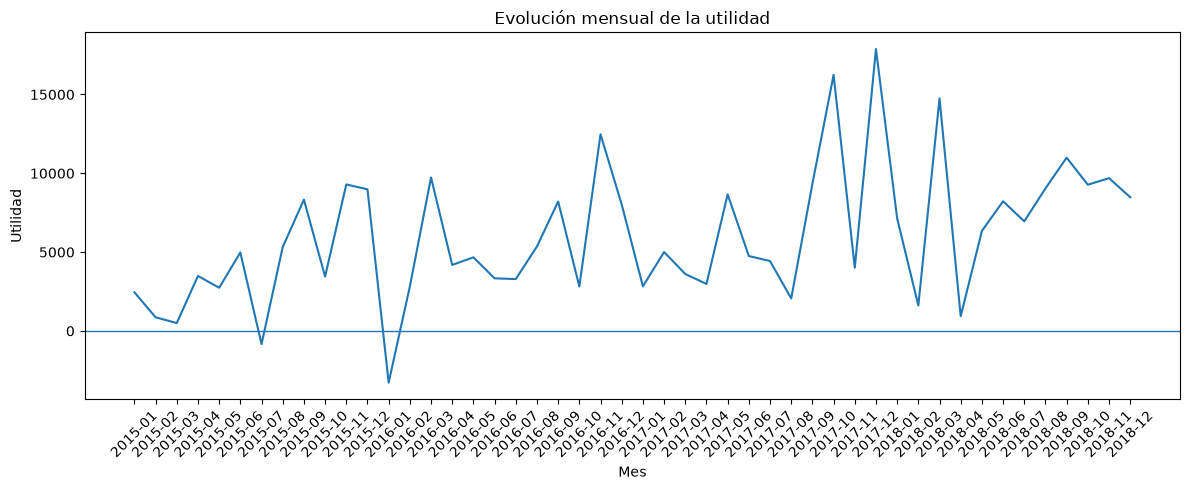

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["Year-Month"].astype(str),
    monthly_financials["Profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Evolución mensual de la utilidad")
plt.xlabel("Mes")
plt.ylabel("Utilidad")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [151]:
plt.tight_layout()

plt.savefig("../images/utilidad_mensual.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

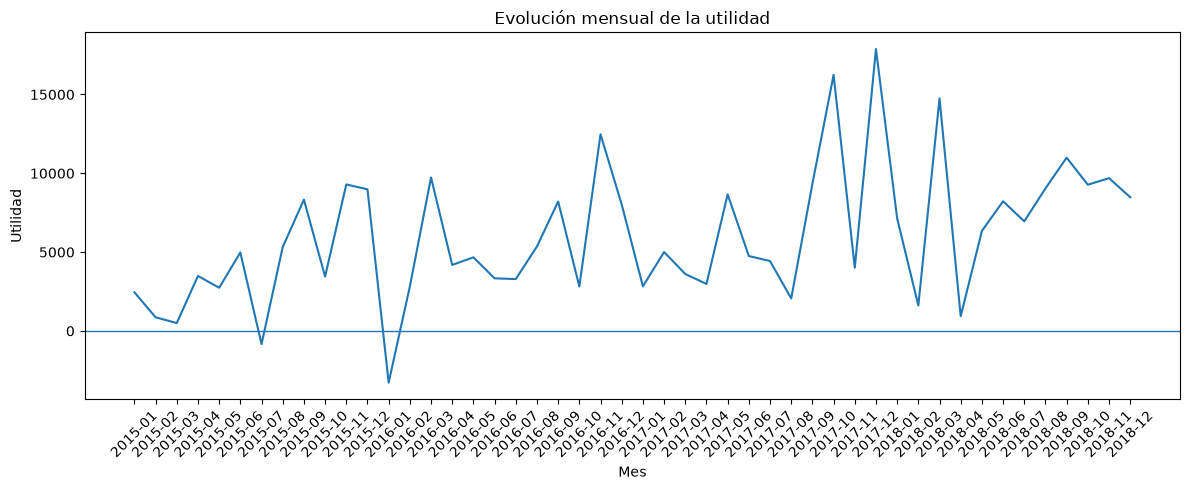

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["Year-Month"].astype(str),
    monthly_financials["Profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Evolución mensual de la utilidad")
plt.xlabel("Mes")
plt.ylabel("Utilidad")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/utilidad_mensual.png", dpi=300, bbox_inches="tight")

plt.show()

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [155]:
%whos

Variable             Type         Data/Info
-------------------------------------------
df                   DataFrame    Shape: (10800, 21)
df_clean             DataFrame    Shape: (9994, 24)
mdates               module       <module 'matplotlib.dates<...>s\\matplotlib\\dates.py'>
monthly_financials   DataFrame    Shape: (48, 5)
pd                   module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt                  module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
total_cost           float64      2010803.8386000001
total_margin         float64      0.12467217240315605
total_profit         float64      286397.0217
total_sales          float64      2297200.8603


In [157]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [158]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [159]:
# Asegurar que Order Date sea de tipo fecha
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Crear período mensual
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)

# Resumen mensual de ventas y rentabilidad
monthly_profit = (
    df.groupby('Year-Month')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
      .reset_index()
)

# Calcular margen de utilidad
monthly_profit['Profit Margin'] = (
    monthly_profit['Profit'] / monthly_profit['Sales'] * 100
)

# Ordenar cronológicamente
monthly_profit = monthly_profit.sort_values('Year-Month')

monthly_profit.head()

,Year-Month,Sales,Profit,Profit Margin
0,2015-01,14236.895,2450.1907,17.210148
1,2015-02,4519.892,862.3084,19.078075
2,2015-03,55691.009,498.7299,0.895530
3,2015-04,28295.345,3488.8352,12.330068
4,2015-05,23648.287,2738.7096,11.581006


In [160]:
monthly_profit.head(12)

,Year-Month,Sales,Profit,Profit Margin
0,2015-01,14236.8950,2450.1907,17.210148
1,2015-02,4519.8920,862.3084,19.078075
2,2015-03,55691.0090,498.7299,0.895530
3,2015-04,28295.3450,3488.8352,12.330068
4,2015-05,23648.2870,2738.7096,11.581006
5,2015-06,34595.1276,4976.5244,14.385044
6,2015-07,33946.3930,-841.4826,-2.478857
7,2015-08,27909.4685,5318.1050,19.054842
8,2015-09,81777.3508,8328.0994,10.183870
9,2015-10,31453.3930,3448.2573,10.963069


In [161]:
monthly_profit.tail()

,Year-Month,Sales,Profit,Profit Margin
43,2018-08,63120.8880,9040.9557,14.323239
44,2018-09,87866.6520,10991.5556,12.509360
45,2018-10,77776.9232,9275.2755,11.925485
46,2018-11,118447.8250,9690.1037,8.180905
47,2018-12,83829.3188,8483.3468,10.119785


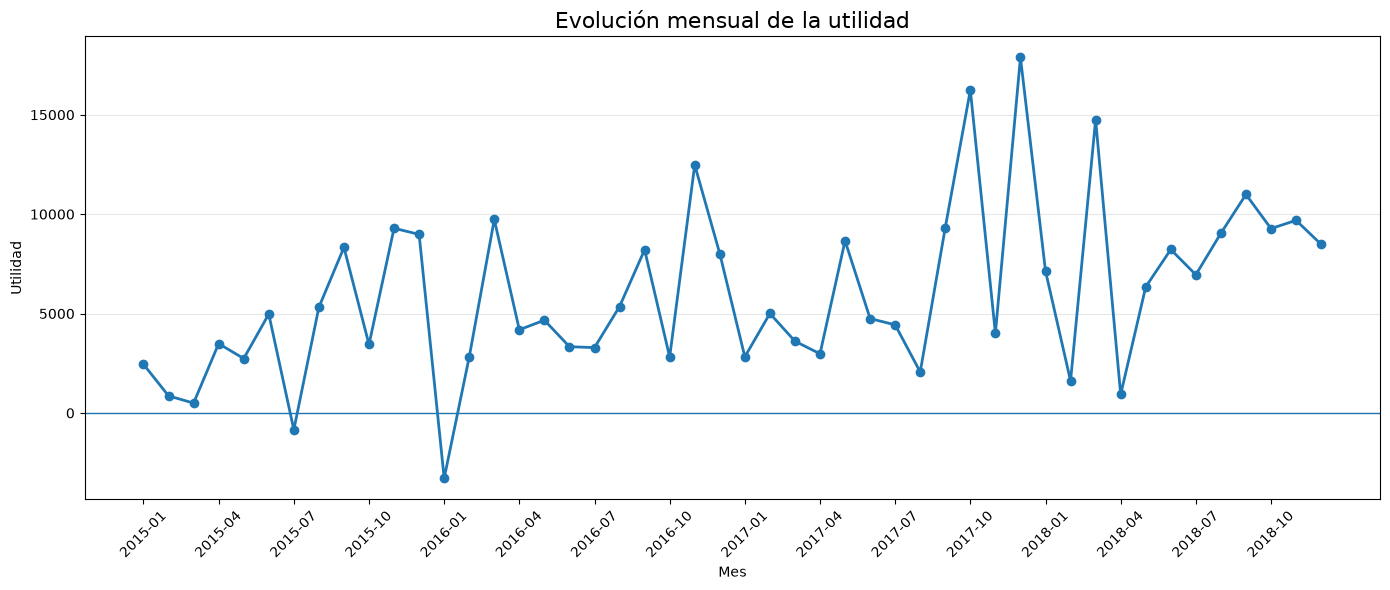

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_profit['Year-Month'],
    monthly_profit['Profit'],
    marker='o',
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.title('Evolución mensual de la utilidad', fontsize=16)
plt.xlabel('Mes')
plt.ylabel('Utilidad')

plt.xticks(
    range(0, len(monthly_profit), 3),
    monthly_profit['Year-Month'].iloc[::3],
    rotation=45
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [166]:
import os

os.path.exists('images/utilidad_mensual.png')

False

In [167]:
import os

print(os.getcwd())

c:\Users\caesa\Python\Proyecto_Rentabilidad\notebooks


In [168]:
print(os.path.exists('images'))

False


In [169]:
import os

os.makedirs('images', exist_ok=True)

print(os.path.exists('images'))

True


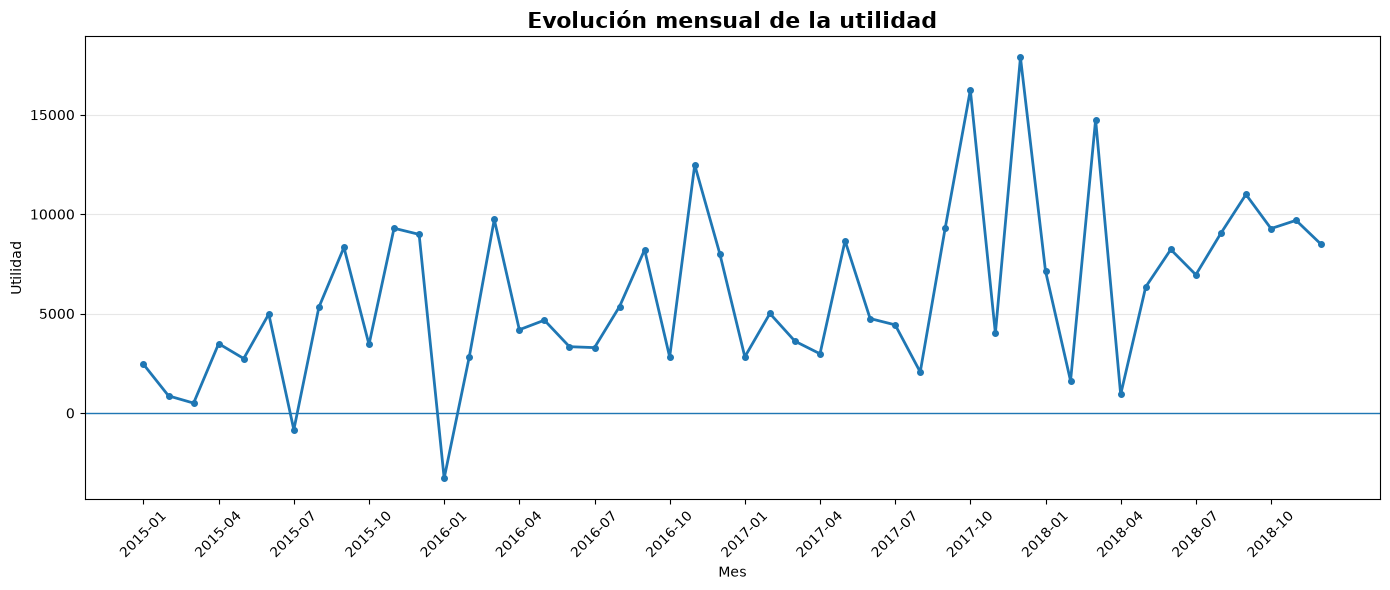

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_profit['Year-Month'],
    monthly_profit['Profit'],
    marker='o',
    linewidth=2,
    markersize=4
)

# Línea de referencia en cero
plt.axhline(0, linewidth=1)

plt.title(
    'Evolución mensual de la utilidad',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Mes')
plt.ylabel('Utilidad')

# Mostrar una etiqueta cada 3 meses
plt.xticks(
    range(0, len(monthly_profit), 3),
    monthly_profit['Year-Month'].iloc[::3],
    rotation=45
)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Guardar el gráfico para el portafolio
plt.savefig(
    'images/utilidad_mensual.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [171]:
os.path.exists('images/utilidad_mensual.png')

True

In [172]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [173]:
category_profit = (
    df.groupby('Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

category_profit['Profit Margin'] = (
    category_profit['Profit'] / category_profit['Sales'] * 100
)

category_profit = category_profit.sort_values(
    'Profit',
    ascending=False
)

category_profit

,Category,Sales,Profit,Quantity,Profit Margin
2,Technology,836154.0330,145454.9481,6939.0,17.395712
1,Office Supplies,719047.0320,122490.8008,22906.0,17.035158
0,Furniture,741999.7953,18451.2728,8028.0,2.486695


In [174]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [175]:
category_profit = (
    df.groupby('Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

# Calcular margen de utilidad
category_profit['Profit Margin'] = (
    category_profit['Profit'] / category_profit['Sales'] * 100
)

# Ordenar de mayor a menor utilidad
category_profit = category_profit.sort_values(
    'Profit',
    ascending=False
)

category_profit

,Category,Sales,Profit,Quantity,Profit Margin
2,Technology,836154.0330,145454.9481,6939.0,17.395712
1,Office Supplies,719047.0320,122490.8008,22906.0,17.035158
0,Furniture,741999.7953,18451.2728,8028.0,2.486695


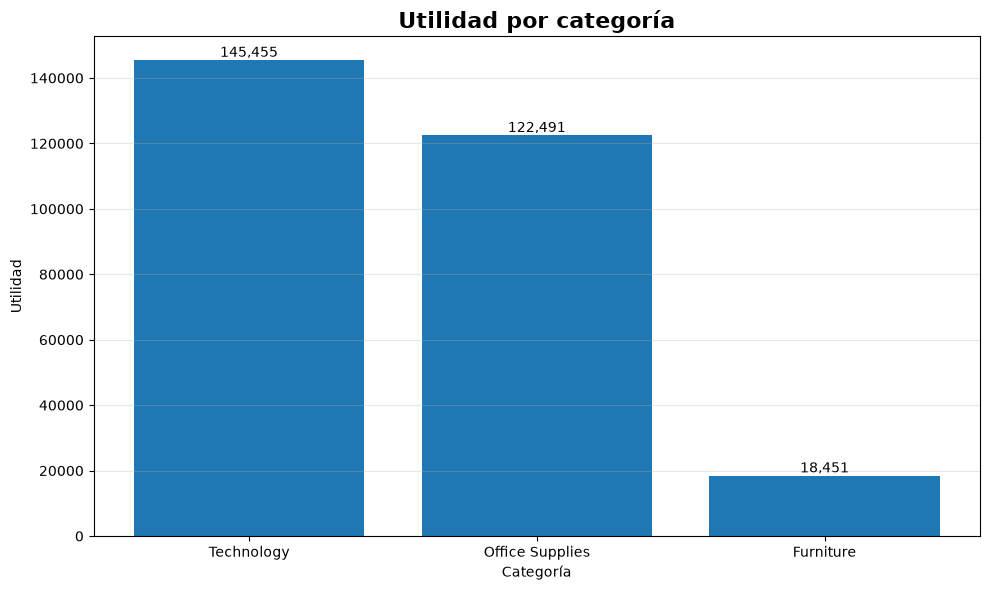

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    category_profit['Category'],
    category_profit['Profit']
)

plt.title(
    'Utilidad por categoría',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Categoría')
plt.ylabel('Utilidad')

plt.grid(
    axis='y',
    alpha=0.3
)

# Mostrar el valor sobre cada barra
for i, value in enumerate(category_profit['Profit']):
    plt.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.show()

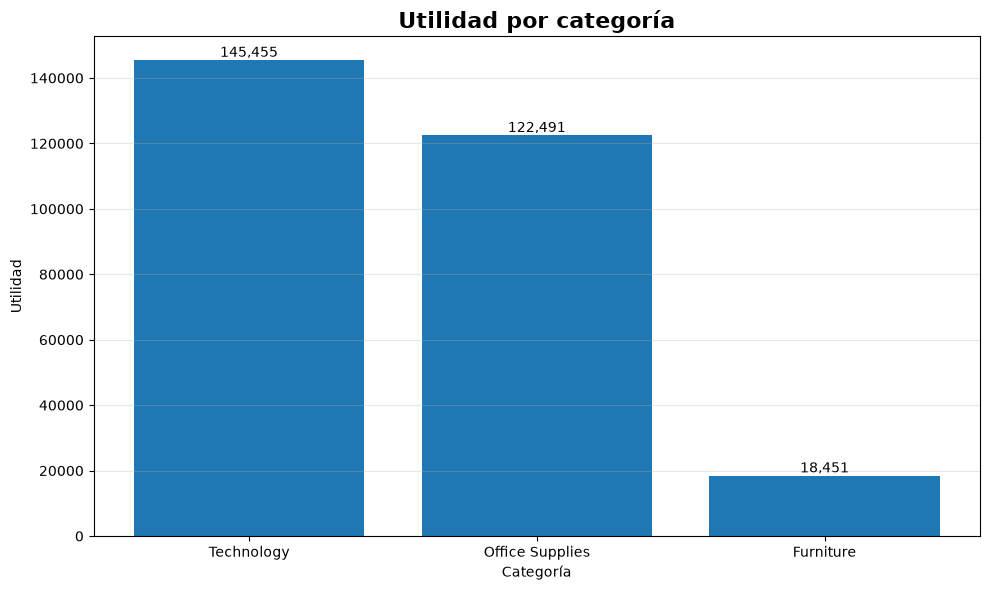

In [178]:
import matplotlib.pyplot as plt
import os

# Crear carpeta images si no existe
os.makedirs('images', exist_ok=True)

plt.figure(figsize=(10, 6))

plt.bar(
    category_profit['Category'],
    category_profit['Profit']
)

plt.title(
    'Utilidad por categoría',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Categoría')
plt.ylabel('Utilidad')

plt.grid(
    axis='y',
    alpha=0.3
)

# Mostrar valores sobre las barras
for i, value in enumerate(category_profit['Profit']):
    plt.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

# Guardar imagen para el portfolio
plt.savefig(
    'images/utilidad_por_categoria.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [179]:
os.path.exists('images/utilidad_por_categoria.png')

True

In [180]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [181]:
subcategory_profit = (
    df.groupby('Sub-Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

# Calcular margen de utilidad
subcategory_profit['Profit Margin'] = (
    subcategory_profit['Profit'] /
    subcategory_profit['Sales'] * 100
)

# Ordenar por utilidad
subcategory_profit = subcategory_profit.sort_values(
    'Profit',
    ascending=False
)

subcategory_profit

,Sub-Category,Sales,Profit,Quantity,Profit Margin
6,Copiers,149528.0300,55617.8249,234.0,37.195585
13,Phones,330007.0540,44515.7306,3289.0,13.489327
0,Accessories,167380.3180,41936.6357,2976.0,25.054700
12,Paper,78479.2060,34053.5693,5178.0,43.391837
3,Binders,203412.7330,30221.7633,5974.0,14.857361
5,Chairs,328449.1030,26590.1663,2356.0,8.095673
14,Storage,223843.6080,21278.8264,3158.0,9.506113
1,Appliances,107532.1610,18138.0054,1729.0,16.867517
9,Furnishings,91705.1640,13059.1436,3563.0,14.240358
7,Envelopes,16476.4020,6964.1767,906.0,42.267582


In [182]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [183]:
subcategory_profit = (
    df.groupby('Sub-Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

subcategory_profit['Profit Margin'] = (
    subcategory_profit['Profit'] /
    subcategory_profit['Sales'] * 100
)

subcategory_profit = subcategory_profit.sort_values(
    'Profit',
    ascending=False
)

subcategory_profit

,Sub-Category,Sales,Profit,Quantity,Profit Margin
6,Copiers,149528.0300,55617.8249,234.0,37.195585
13,Phones,330007.0540,44515.7306,3289.0,13.489327
0,Accessories,167380.3180,41936.6357,2976.0,25.054700
12,Paper,78479.2060,34053.5693,5178.0,43.391837
3,Binders,203412.7330,30221.7633,5974.0,14.857361
5,Chairs,328449.1030,26590.1663,2356.0,8.095673
14,Storage,223843.6080,21278.8264,3158.0,9.506113
1,Appliances,107532.1610,18138.0054,1729.0,16.867517
9,Furnishings,91705.1640,13059.1436,3563.0,14.240358
7,Envelopes,16476.4020,6964.1767,906.0,42.267582


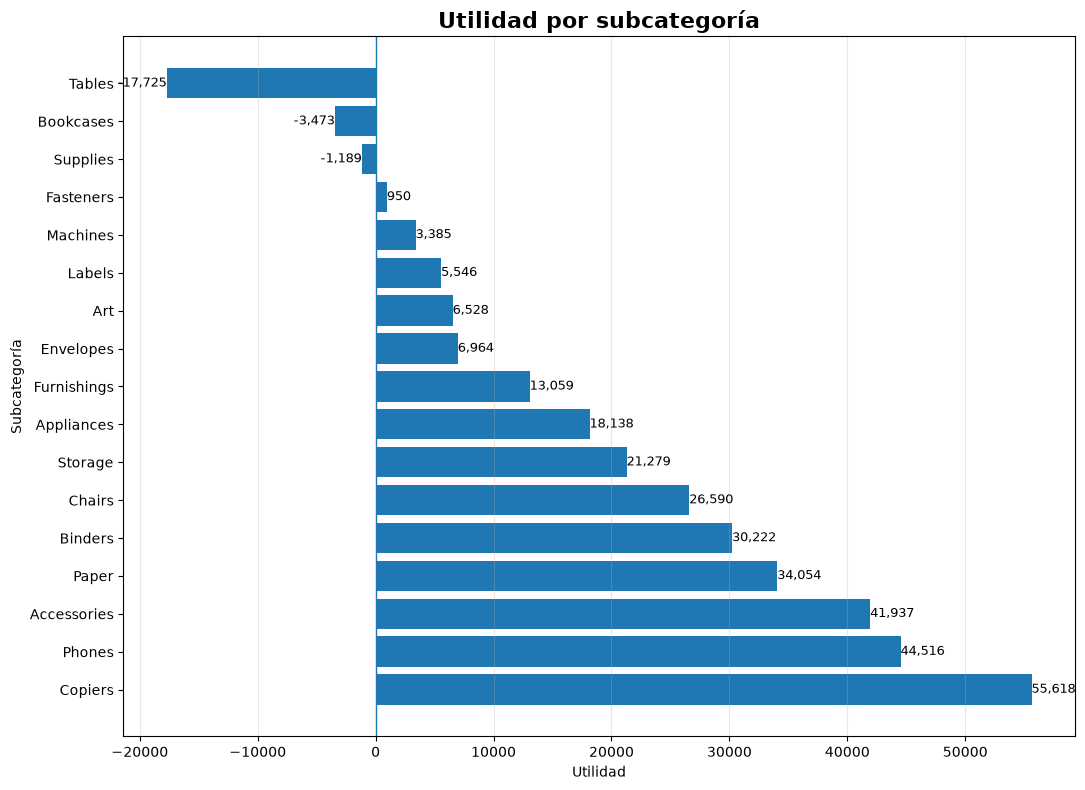

In [184]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

plt.figure(figsize=(11, 8))

plt.barh(
    subcategory_profit['Sub-Category'],
    subcategory_profit['Profit']
)

plt.axvline(0, linewidth=1)

plt.title(
    'Utilidad por subcategoría',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Utilidad')
plt.ylabel('Subcategoría')

plt.grid(
    axis='x',
    alpha=0.3
)

for i, value in enumerate(subcategory_profit['Profit']):
    if value >= 0:
        plt.text(
            value,
            i,
            f'{value:,.0f}',
            va='center',
            ha='left',
            fontsize=9
        )
    else:
        plt.text(
            value,
            i,
            f'{value:,.0f}',
            va='center',
            ha='right',
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    'images/utilidad_por_subcategoria.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [185]:
os.path.exists('images/utilidad_por_subcategoria.png')

True

In [186]:
discount_profit = (
    df.groupby('Discount')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

discount_profit['Profit Margin'] = (
    discount_profit['Profit'] /
    discount_profit['Sales'] * 100
)

discount_profit = discount_profit.sort_values('Discount')

discount_profit

,Discount,Sales,Profit,Quantity,Profit Margin
0,0.00,1.087908e+06,320987.6032,18267.0,29.505019
1,0.10,5.436935e+04,9029.1770,373.0,16.607108
2,0.15,2.755852e+04,1418.9915,198.0,5.149012
3,0.20,7.645944e+05,90337.3060,13660.0,11.815063
4,0.30,1.032267e+05,-10369.2774,849.0,-10.045155
5,0.32,1.449346e+04,-2391.1377,105.0,-16.498047
6,0.40,1.164178e+05,-23057.0504,786.0,-19.805437
7,0.45,5.484974e+03,-2493.1111,45.0,-45.453472
8,0.50,5.891854e+04,-20506.4281,241.0,-34.804712
9,0.60,6.644700e+03,-5944.6552,501.0,-89.464614


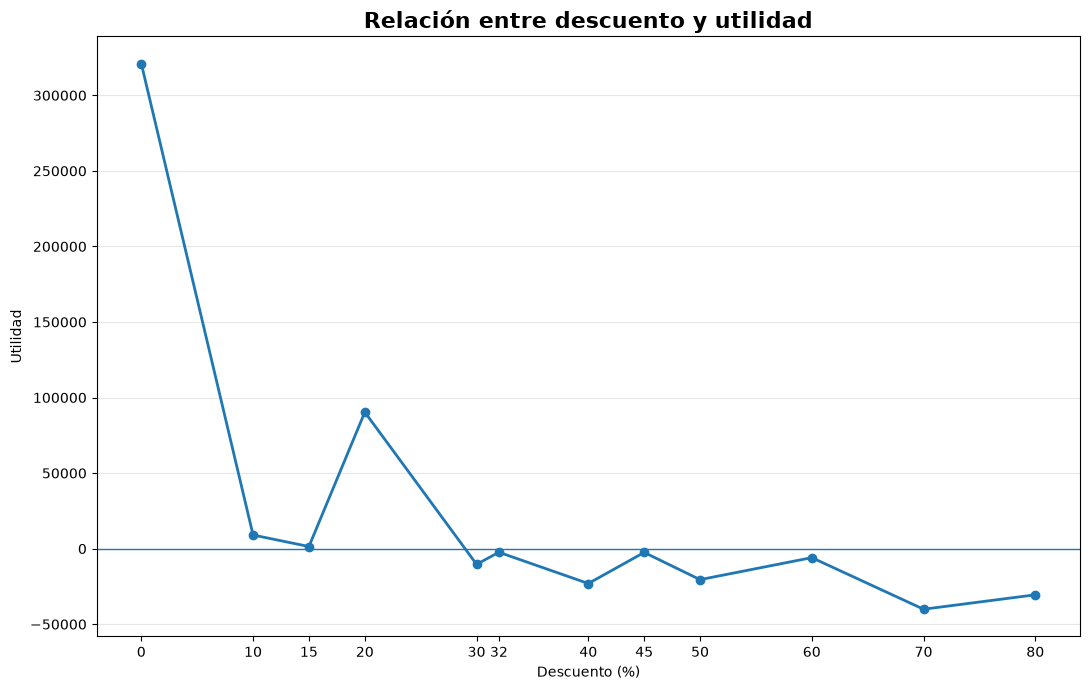

In [187]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

plt.figure(figsize=(11, 7))

plt.plot(
    discount_profit['Discount'] * 100,
    discount_profit['Profit'],
    marker='o',
    linewidth=2,
    markersize=6
)

plt.axhline(0, linewidth=1)

plt.title(
    'Relación entre descuento y utilidad',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Descuento (%)')
plt.ylabel('Utilidad')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.xticks(
    discount_profit['Discount'] * 100
)

plt.tight_layout()

plt.savefig(
    'images/utilidad_por_descuento.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [188]:
os.path.exists('images/utilidad_por_descuento.png')

True

In [189]:
discount_category = (
    df.groupby(['Category', 'Discount'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

discount_category['Profit Margin'] = (
    discount_category['Profit'] /
    discount_category['Sales'] * 100
)

discount_category

,Category,Discount,Sales,Profit,Quantity,Profit Margin
0,Furniture,0.00,256025.2700,58133.0764,3224.0,22.705992
1,Furniture,0.10,46634.2470,7111.0119,313.0,15.248476
2,Furniture,0.15,27558.5215,1418.9915,198.0,5.149012
3,Furniture,0.20,216631.0160,6265.9491,2236.0,2.892452
4,Furniture,0.30,99470.3500,-10695.3169,837.0,-10.752266
5,Furniture,0.32,14493.4588,-2391.1377,105.0,-16.498047
6,Furniture,0.40,45614.4060,-16187.3968,292.0,-35.487466
7,Furniture,0.45,5484.9740,-2493.1111,45.0,-45.453472
8,Furniture,0.50,20983.4700,-12871.1990,209.0,-61.339707
9,Furniture,0.60,6644.7000,-5944.6552,501.0,-89.464614


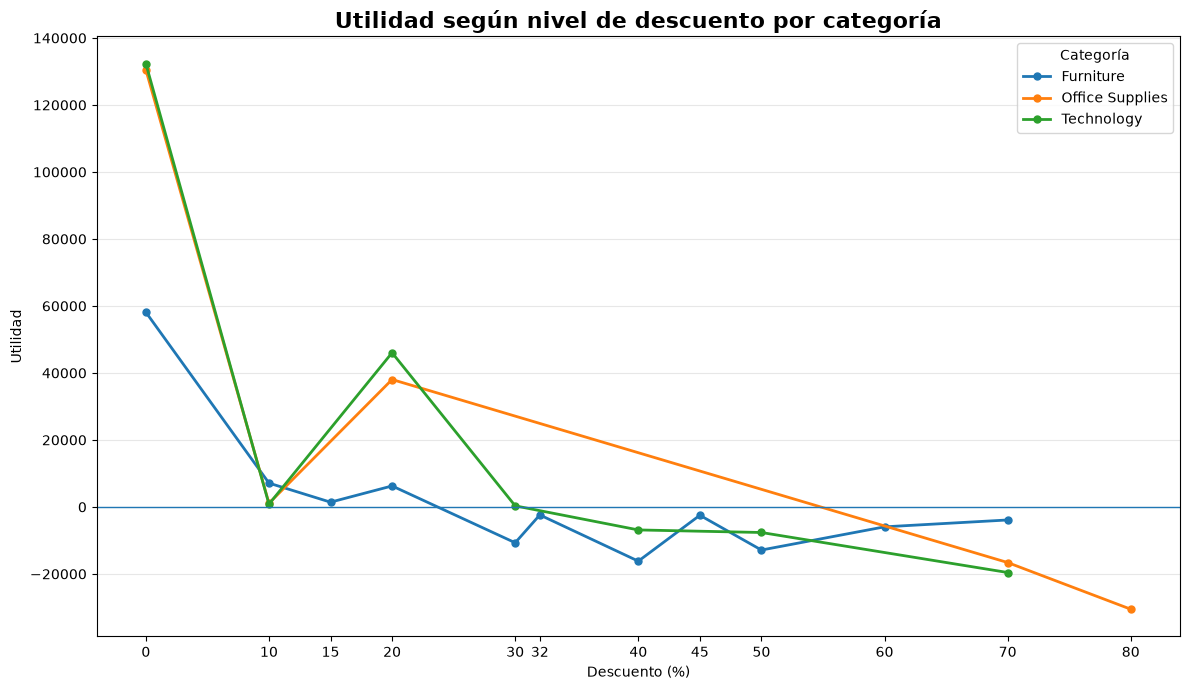

In [190]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

plt.figure(figsize=(12, 7))

for category in discount_category['Category'].unique():

    data = discount_category[
        discount_category['Category'] == category
    ]

    plt.plot(
        data['Discount'] * 100,
        data['Profit'],
        marker='o',
        linewidth=2,
        markersize=5,
        label=category
    )

plt.axhline(0, linewidth=1)

plt.title(
    'Utilidad según nivel de descuento por categoría',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Descuento (%)')
plt.ylabel('Utilidad')

plt.xticks(
    sorted(discount_category['Discount'].unique() * 100)
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.legend(
    title='Categoría'
)

plt.tight_layout()

plt.savefig(
    'images/utilidad_descuento_categoria.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [191]:
os.path.exists('images/utilidad_descuento_categoria.png')

True

In [192]:
product_profit = (
    df.groupby(['Product ID', 'Product Name'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

product_profit['Profit Margin'] = (
    product_profit['Profit'] /
    product_profit['Sales'] * 100
)

product_profit = product_profit.sort_values(
    'Profit',
    ascending=False
)

product_profit.head(10)

,Product ID,Product Name,Sales,Profit,Quantity,Profit Margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20.0,40.909091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31.0,28.240741
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38.0,37.070064
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19.0,39.337349
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12.0,22.285714
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11.0,49.000000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11.0,26.000000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24.0,39.459459
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13.0,21.071429
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6.0,48.000000


In [193]:
product_loss = (
    df.groupby(['Product ID', 'Product Name'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

product_loss['Profit Margin'] = (
    product_loss['Profit'] /
    product_loss['Sales'] * 100
)

product_loss = product_loss.sort_values(
    'Profit',
    ascending=True
)

product_loss.head(10)

,Product ID,Product Name,Sales,Profit,Quantity,Profit Margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9.0,-80.000000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18.0,-27.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4.0,-48.000000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27.0,-29.000000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33.0,-20.266667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27.0,-10.454545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6.0,-8.000000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22.0,-7.800000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19.0,-18.424658
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15.0,-67.307692


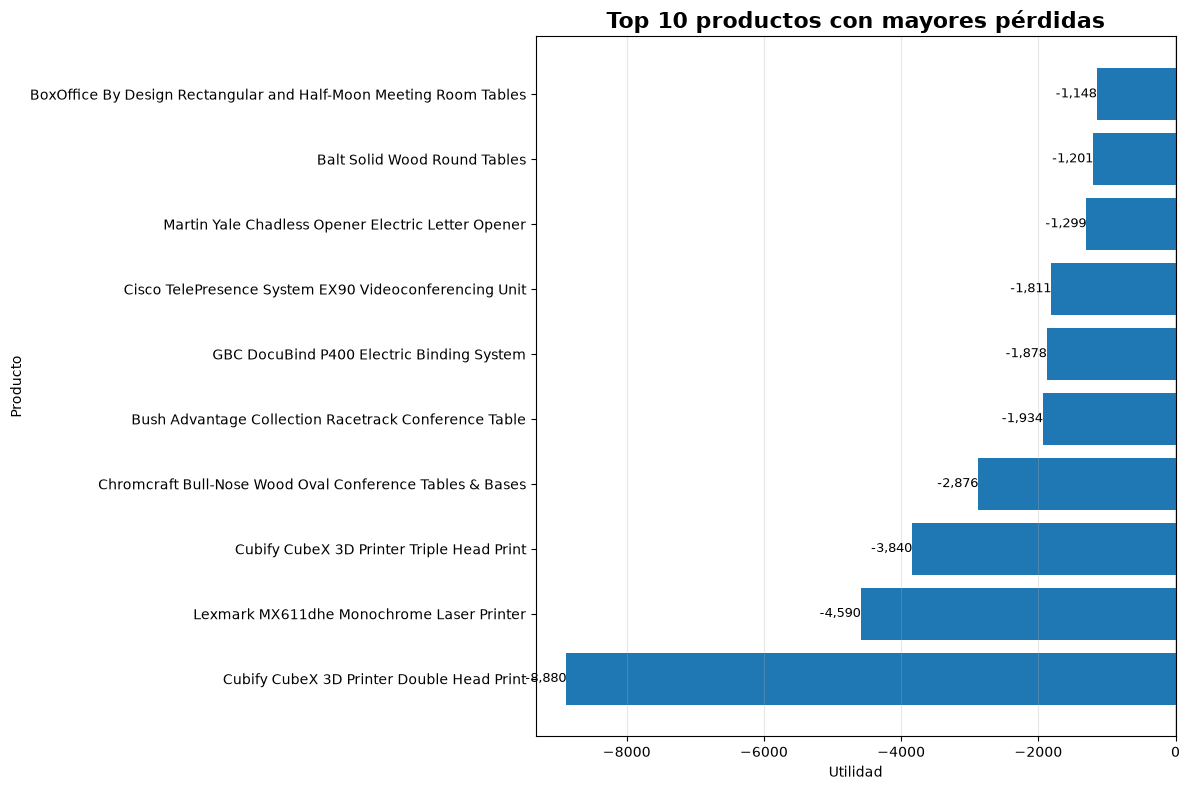

In [194]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

loss_chart = product_loss.head(10).sort_values('Profit')

plt.figure(figsize=(12, 8))

plt.barh(
    loss_chart['Product Name'],
    loss_chart['Profit']
)

plt.axvline(0, linewidth=1)

plt.title(
    'Top 10 productos con mayores pérdidas',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Utilidad')
plt.ylabel('Producto')

plt.grid(
    axis='x',
    alpha=0.3
)

for i, value in enumerate(loss_chart['Profit']):
    plt.text(
        value,
        i,
        f'{value:,.0f}',
        va='center',
        ha='right',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    'images/top_productos_perdidas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [195]:
os.path.exists('images/top_productos_perdidas.png')

True

In [196]:
region_profit = (
    df.groupby('Region')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

region_profit['Profit Margin'] = (
    region_profit['Profit'] /
    region_profit['Sales'] * 100
)

region_profit = region_profit.sort_values(
    'Profit',
    ascending=False
)

region_profit

,Region,Sales,Profit,Quantity,Profit Margin
3,West,725457.8245,108418.4489,12266.0,14.944831
1,East,678781.2400,91522.7800,10618.0,13.483399
2,South,391721.9050,46749.4303,6209.0,11.934342
0,Central,501239.8908,39706.3625,8780.0,7.921629


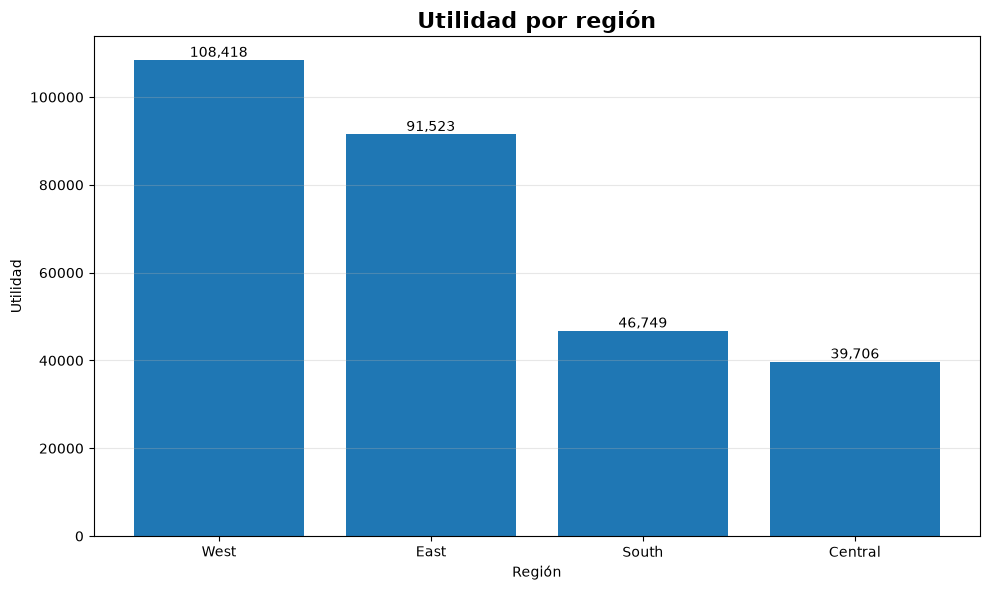

In [197]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

plt.figure(figsize=(10, 6))

plt.bar(
    region_profit['Region'],
    region_profit['Profit']
)

plt.title(
    'Utilidad por región',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Región')
plt.ylabel('Utilidad')

plt.grid(
    axis='y',
    alpha=0.3
)

for i, value in enumerate(region_profit['Profit']):
    plt.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    'images/rentabilidad_region.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [198]:
os.path.exists('images/rentabilidad_region.png')

True

In [199]:
segment_profit = (
    df.groupby('Segment')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

segment_profit['Profit Margin'] = (
    segment_profit['Profit'] /
    segment_profit['Sales'] * 100
)

segment_profit = segment_profit.sort_values(
    'Profit',
    ascending=False
)

segment_profit

,Segment,Sales,Profit,Quantity,Profit Margin
0,Consumer,1.161401e+06,134119.2092,19521.0,11.548050
1,Corporate,7.061464e+05,91979.1340,11608.0,13.025506
2,Home Office,4.296531e+05,60298.6785,6744.0,14.034269


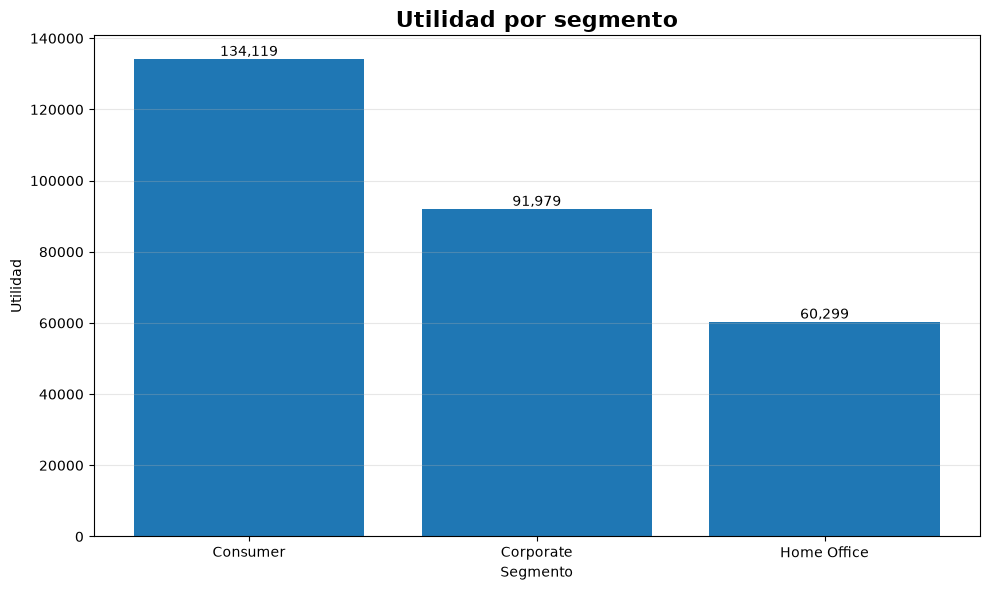

In [200]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_profit['Segment'],
    segment_profit['Profit']
)

plt.title(
    'Utilidad por segmento',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Segmento')
plt.ylabel('Utilidad')

plt.grid(
    axis='y',
    alpha=0.3
)

for i, value in enumerate(segment_profit['Profit']):
    plt.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    'images/rentabilidad_segmento.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [201]:
os.path.exists('images/rentabilidad_segmento.png')

True

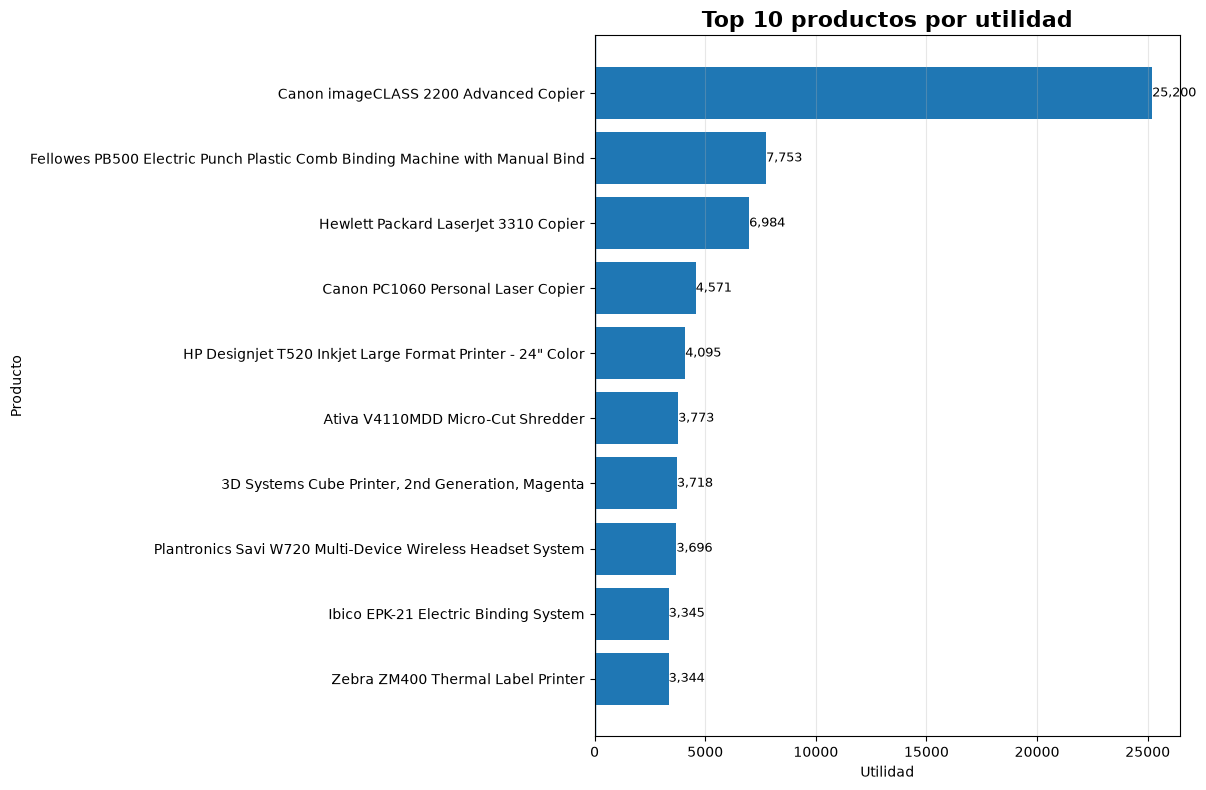

In [202]:
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

profit_chart = (
    product_profit
    .head(10)
    .sort_values('Profit')
)

plt.figure(figsize=(12, 8))

plt.barh(
    profit_chart['Product Name'],
    profit_chart['Profit']
)

plt.axvline(0, linewidth=1)

plt.title(
    'Top 10 productos por utilidad',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Utilidad')
plt.ylabel('Producto')

plt.grid(
    axis='x',
    alpha=0.3
)

for i, value in enumerate(profit_chart['Profit']):
    plt.text(
        value,
        i,
        f'{value:,.0f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    'images/top_productos_utilidad.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [203]:
os.path.exists('images/top_productos_utilidad.png')

True

In [204]:
monthly_profit.loc[
    monthly_profit['Profit'].idxmax()
]

Year-Month          2017-12
Sales             96999.043
Profit           17885.3093
Profit Margin     18.438645
Name: 35, dtype: object

In [205]:
monthly_profit.loc[
    monthly_profit['Profit'].idxmin()
]

Year-Month          2016-01
Sales            18174.0756
Profit            -3281.007
Profit Margin    -18.053226
Name: 12, dtype: object

In [206]:
category_profit

,Category,Sales,Profit,Quantity,Profit Margin
2,Technology,836154.0330,145454.9481,6939.0,17.395712
1,Office Supplies,719047.0320,122490.8008,22906.0,17.035158
0,Furniture,741999.7953,18451.2728,8028.0,2.486695


In [207]:
subcategory_profit


,Sub-Category,Sales,Profit,Quantity,Profit Margin
6,Copiers,149528.0300,55617.8249,234.0,37.195585
13,Phones,330007.0540,44515.7306,3289.0,13.489327
0,Accessories,167380.3180,41936.6357,2976.0,25.054700
12,Paper,78479.2060,34053.5693,5178.0,43.391837
3,Binders,203412.7330,30221.7633,5974.0,14.857361
5,Chairs,328449.1030,26590.1663,2356.0,8.095673
14,Storage,223843.6080,21278.8264,3158.0,9.506113
1,Appliances,107532.1610,18138.0054,1729.0,16.867517
9,Furnishings,91705.1640,13059.1436,3563.0,14.240358
7,Envelopes,16476.4020,6964.1767,906.0,42.267582


In [208]:
discount_profit

,Discount,Sales,Profit,Quantity,Profit Margin
0,0.00,1.087908e+06,320987.6032,18267.0,29.505019
1,0.10,5.436935e+04,9029.1770,373.0,16.607108
2,0.15,2.755852e+04,1418.9915,198.0,5.149012
3,0.20,7.645944e+05,90337.3060,13660.0,11.815063
4,0.30,1.032267e+05,-10369.2774,849.0,-10.045155
5,0.32,1.449346e+04,-2391.1377,105.0,-16.498047
6,0.40,1.164178e+05,-23057.0504,786.0,-19.805437
7,0.45,5.484974e+03,-2493.1111,45.0,-45.453472
8,0.50,5.891854e+04,-20506.4281,241.0,-34.804712
9,0.60,6.644700e+03,-5944.6552,501.0,-89.464614


In [209]:
region_profit

,Region,Sales,Profit,Quantity,Profit Margin
3,West,725457.8245,108418.4489,12266.0,14.944831
1,East,678781.2400,91522.7800,10618.0,13.483399
2,South,391721.9050,46749.4303,6209.0,11.934342
0,Central,501239.8908,39706.3625,8780.0,7.921629


In [210]:
segment_profit

,Segment,Sales,Profit,Quantity,Profit Margin
0,Consumer,1.161401e+06,134119.2092,19521.0,11.548050
1,Corporate,7.061464e+05,91979.1340,11608.0,13.025506
2,Home Office,4.296531e+05,60298.6785,6744.0,14.034269


In [211]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales * 100
total_quantity = df['Quantity'].sum()

print(f'Ventas totales: {total_sales:,.2f}')
print(f'Utilidad total: {total_profit:,.2f}')
print(f'Margen de utilidad: {profit_margin:.2f}%')
print(f'Unidades vendidas: {total_quantity:,.0f}')

Ventas totales: 2,297,200.86
Utilidad total: 286,397.02
Margen de utilidad: 12.47%
Unidades vendidas: 37,873


In [212]:
total_products = product_profit.shape[0]

loss_products = (
    product_profit['Profit'] < 0
).sum()

profitable_products = (
    product_profit['Profit'] > 0
).sum()

zero_profit_products = (
    product_profit['Profit'] == 0
).sum()

print(f'Total de productos: {total_products}')
print(f'Productos con pérdida: {loss_products}')
print(f'Productos con utilidad positiva: {profitable_products}')
print(f'Productos con utilidad cero: {zero_profit_products}')
print(
    f'% de productos con pérdida: '
    f'{loss_products / total_products * 100:.2f}%'
)

Total de productos: 1894
Productos con pérdida: 306
Productos con utilidad positiva: 1585
Productos con utilidad cero: 3
% de productos con pérdida: 16.16%


In [213]:
loss_product_profit = product_profit.loc[
    product_profit['Profit'] < 0,
    'Profit'
].sum()

positive_product_profit = product_profit.loc[
    product_profit['Profit'] > 0,
    'Profit'
].sum()

print(f'Utilidad generada por productos rentables: {positive_product_profit:,.2f}')
print(f'Pérdida acumulada de productos con pérdida: {loss_product_profit:,.2f}')
print(
    f'Pérdida acumulada como % de la utilidad total: '
    f'{abs(loss_product_profit) / total_profit * 100:.2f}%'
)

Utilidad generada por productos rentables: 363,489.04
Pérdida acumulada de productos con pérdida: -77,092.02
Pérdida acumulada como % de la utilidad total: 26.92%


In [214]:
loss_by_category = (
    df[df['Profit'] < 0]
    .groupby('Category')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

loss_by_category = loss_by_category.sort_values(
    'Profit',
    ascending=True
)

loss_by_category

,Category,Sales,Profit,Quantity
0,Furniture,257885.5868,-60936.1090,2652.0
1,Office Supplies,91608.6750,-56615.2585,3425.0
2,Technology,119212.8930,-38579.9182,963.0


In [215]:
loss_by_subcategory = (
    df[df['Profit'] < 0]
    .groupby('Sub-Category')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

loss_by_subcategory = loss_by_subcategory.sort_values(
    'Profit',
    ascending=True
)

loss_by_subcategory

,Sub-Category,Sales,Profit,Quantity
2,Binders,36140.6130,-38510.4964,2456.0
11,Tables,104978.5460,-32412.1483,757.0
7,Machines,72456.2530,-30118.6682,157.0
3,Bookcases,48072.7408,-12152.2060,422.0
4,Chairs,91988.4560,-9880.8413,876.0
1,Appliances,3382.5340,-8629.6412,235.0
8,Phones,35797.8400,-7530.6235,476.0
6,Furnishings,12845.8440,-6490.9134,597.0
9,Storage,37869.0720,-6426.3038,569.0
10,Supplies,14067.1760,-3015.6219,110.0


In [216]:
top_loss_transactions = (
    df[['Order ID', 'Order Date', 'Product Name', 'Category',
        'Sub-Category', 'Sales', 'Discount', 'Profit']]
    .sort_values('Profit', ascending=True)
    .head(10)
)

top_loss_transactions

,Order ID,Order Date,Product Name,Category,Sub-Category,Sales,Discount,Profit
7772,CA-2017-108196,2017-11-25,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,4499.985,0.7,-6599.9780
683,US-2018-168116,2018-11-04,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,0.5,-3839.9904
9774,CA-2015-169019,2015-07-26,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,2177.584,0.8,-3701.8928
3011,CA-2018-134845,2018-04-17,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,2549.985,0.7,-3399.9800
4991,US-2018-122714,2018-12-07,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,1889.990,0.8,-2929.4845
3151,CA-2016-147830,2016-12-15,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,1799.994,0.7,-2639.9912
5310,CA-2018-131254,2018-11-19,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,1525.188,0.8,-2287.7820
9639,CA-2016-116638,2016-01-28,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,4297.644,0.4,-1862.3124
1199,CA-2017-130946,2017-04-08,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,1088.792,0.8,-1850.9464
2697,CA-2015-145317,2015-03-18,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,0.5,-1811.0784


In [217]:
executive_summary = pd.DataFrame({
    'KPI': [
        'Ventas totales',
        'Utilidad total',
        'Margen de utilidad',
        'Productos analizados',
        'Productos con pérdida',
        'Mes con mayor utilidad',
        'Mes con menor utilidad'
    ],
    'Resultado': [
        f"${df['Sales'].sum():,.2f}",
        f"${df['Profit'].sum():,.2f}",
        f"{(df['Profit'].sum() / df['Sales'].sum()) * 100:.2f}%",
        f"{product_profit.shape[0]:,}",
        f"{(product_profit['Profit'] < 0).sum():,}",
        '2017-12',
        '2016-01'
    ]
})

executive_summary

,KPI,Resultado
0,Ventas totales,"$2,297,200.86"
1,Utilidad total,"$286,397.02"
2,Margen de utilidad,12.47%
3,Productos analizados,"1,894"
4,Productos con pérdida,306
5,Mes con mayor utilidad,2017-12
6,Mes con menor utilidad,2016-01


In [220]:
import os

print(os.getcwd())

c:\Users\caesa\Python\Proyecto_Rentabilidad\notebooks


In [221]:
print(os.listdir())

['analisis_rentabilidad.ipynb', 'images']


In [222]:
import sqlite3
import os

db_path = os.path.join('..', 'data', 'proyecto_rentabilidad.db')

conn = sqlite3.connect(db_path)

print("Conexión SQLite creada correctamente")
print(db_path)

Conexión SQLite creada correctamente
..\data\proyecto_rentabilidad.db


In [223]:
df.to_sql(
    'sales',
    conn,
    if_exists='replace',
    index=False
)

print("Tabla 'sales' creada correctamente")

Tabla 'sales' creada correctamente


In [224]:
pd.read_sql_query(
    "SELECT COUNT(*) AS total_registros FROM sales",
    conn
)

,total_registros
0,10800


In [225]:
df.to_sql(
    'sales',
    conn,
    if_exists='replace',
    index=False
)

print("Tabla 'sales' creada correctamente")

Tabla 'sales' creada correctamente


In [226]:
pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_registros
    FROM sales;
    """,
    conn
)

,total_registros
0,10800


In [227]:
print("Filas de df:", len(df))
print("Columnas de df:", len(df.columns))

Filas de df: 10800
Columnas de df: 22


In [228]:
df.isna().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
Year-Month       806
dtype: int64

In [229]:
df_sql = df.dropna(subset=['Sales']).copy()

print("Registros originales:", len(df))
print("Registros para SQL:", len(df_sql))
print("Valores nulos en Sales:", df_sql['Sales'].isna().sum())

Registros originales: 10800
Registros para SQL: 9994
Valores nulos en Sales: 0


In [230]:
df_sql.to_sql(
    'sales',
    conn,
    if_exists='replace',
    index=False
)

print("Tabla 'sales' actualizada correctamente")


Tabla 'sales' actualizada correctamente


In [231]:
pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_registros
    FROM sales;
    """,
    conn
)

,total_registros
0,9994


In [232]:
query_kpis = """
SELECT
    COUNT(*) AS total_registros,
    COUNT(DISTINCT "Order ID") AS total_ordenes,
    COUNT(DISTINCT "Customer ID") AS total_clientes,
    SUM("Sales") AS ventas_totales,
    SUM("Profit") AS utilidad_total,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales;
"""

kpis_sql = pd.read_sql_query(query_kpis, conn)

kpis_sql

,total_registros,total_ordenes,total_clientes,ventas_totales,utilidad_total,margen_utilidad
0,9994,5009,793,2.297201e+06,286397.0217,12.467217


In [233]:
query_categoria = """
SELECT
    "Category" AS categoria,
    SUM("Sales") AS ventas,
    SUM("Profit") AS utilidad,
    SUM("Quantity") AS cantidad,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales
GROUP BY "Category"
ORDER BY utilidad DESC;
"""

categoria_sql = pd.read_sql_query(query_categoria, conn)

categoria_sql

,categoria,ventas,utilidad,cantidad,margen_utilidad
0,Technology,836154.0330,145454.9481,6939.0,17.395712
1,Office Supplies,719047.0320,122490.8008,22906.0,17.035158
2,Furniture,741999.7953,18451.2728,8028.0,2.486695


In [234]:
query_subcategoria = """
SELECT
    "Sub-Category" AS subcategoria,
    SUM("Sales") AS ventas,
    SUM("Profit") AS utilidad,
    SUM("Quantity") AS cantidad,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales
GROUP BY "Sub-Category"
ORDER BY utilidad DESC;
"""

subcategoria_sql = pd.read_sql_query(query_subcategoria, conn)

subcategoria_sql

,subcategoria,ventas,utilidad,cantidad,margen_utilidad
0,Copiers,149528.0300,55617.8249,234.0,37.195585
1,Phones,330007.0540,44515.7306,3289.0,13.489327
2,Accessories,167380.3180,41936.6357,2976.0,25.054700
3,Paper,78479.2060,34053.5693,5178.0,43.391837
4,Binders,203412.7330,30221.7633,5974.0,14.857361
5,Chairs,328449.1030,26590.1663,2356.0,8.095673
6,Storage,223843.6080,21278.8264,3158.0,9.506113
7,Appliances,107532.1610,18138.0054,1729.0,16.867517
8,Furnishings,91705.1640,13059.1436,3563.0,14.240358
9,Envelopes,16476.4020,6964.1767,906.0,42.267582


In [235]:
query_descuento = """
SELECT
    "Discount" AS descuento,
    SUM("Sales") AS ventas,
    SUM("Profit") AS utilidad,
    SUM("Quantity") AS cantidad,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales
GROUP BY "Discount"
ORDER BY descuento;
"""

descuento_sql = pd.read_sql_query(query_descuento, conn)

descuento_sql

,descuento,ventas,utilidad,cantidad,margen_utilidad
0,0.00,1.087908e+06,320987.6032,18267.0,29.505019
1,0.10,5.436935e+04,9029.1770,373.0,16.607108
2,0.15,2.755852e+04,1418.9915,198.0,5.149012
3,0.20,7.645944e+05,90337.3060,13660.0,11.815063
4,0.30,1.032267e+05,-10369.2774,849.0,-10.045155
5,0.32,1.449346e+04,-2391.1377,105.0,-16.498047
6,0.40,1.164178e+05,-23057.0504,786.0,-19.805437
7,0.45,5.484974e+03,-2493.1111,45.0,-45.453472
8,0.50,5.891854e+04,-20506.4281,241.0,-34.804712
9,0.60,6.644700e+03,-5944.6552,501.0,-89.464614


In [236]:
query_region = """
SELECT
    "Region" AS region,
    SUM("Sales") AS ventas,
    SUM("Profit") AS utilidad,
    SUM("Quantity") AS cantidad,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales
GROUP BY "Region"
ORDER BY utilidad DESC;
"""

region_sql = pd.read_sql_query(query_region, conn)

region_sql

,region,ventas,utilidad,cantidad,margen_utilidad
0,West,725457.8245,108418.4489,12266.0,14.944831
1,East,678781.2400,91522.7800,10618.0,13.483399
2,South,391721.9050,46749.4303,6209.0,11.934342
3,Central,501239.8908,39706.3625,8780.0,7.921629


In [237]:
query_segmento = """
SELECT
    "Segment" AS segmento,
    SUM("Sales") AS ventas,
    SUM("Profit") AS utilidad,
    SUM("Quantity") AS cantidad,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales
GROUP BY "Segment"
ORDER BY utilidad DESC;
"""

segmento_sql = pd.read_sql_query(query_segmento, conn)

segmento_sql

,segmento,ventas,utilidad,cantidad,margen_utilidad
0,Consumer,1.161401e+06,134119.2092,19521.0,11.548050
1,Corporate,7.061464e+05,91979.1340,11608.0,13.025506
2,Home Office,4.296531e+05,60298.6785,6744.0,14.034269


In [238]:
query_productos_perdida = """
SELECT
    "Product ID" AS product_id,
    "Product Name" AS product_name,
    SUM("Sales") AS ventas,
    SUM("Profit") AS utilidad,
    SUM("Quantity") AS cantidad,
    SUM("Profit") / NULLIF(SUM("Sales"), 0) * 100 AS margen_utilidad
FROM sales
GROUP BY "Product ID", "Product Name"
HAVING SUM("Profit") < 0
ORDER BY utilidad ASC
LIMIT 10;
"""

productos_perdida_sql = pd.read_sql_query(
    query_productos_perdida,
    conn
)

productos_perdida_sql

,product_id,product_name,ventas,utilidad,cantidad,margen_utilidad
0,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9.0,-80.000000
1,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18.0,-27.272727
2,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4.0,-48.000000
3,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27.0,-29.000000
4,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33.0,-20.266667
5,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27.0,-10.454545
6,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6.0,-8.000000
7,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22.0,-7.800000
8,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19.0,-18.424658
9,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15.0,-67.307692


In [239]:
query_productos_resumen = """
SELECT
    COUNT(*) AS total_productos,
    SUM(CASE WHEN utilidad > 0 THEN 1 ELSE 0 END) AS productos_rentables,
    SUM(CASE WHEN utilidad < 0 THEN 1 ELSE 0 END) AS productos_con_perdida,
    SUM(CASE WHEN utilidad = 0 THEN 1 ELSE 0 END) AS productos_sin_utilidad
FROM (
    SELECT
        "Product ID",
        SUM("Profit") AS utilidad
    FROM sales
    GROUP BY "Product ID"
) AS productos;
"""

productos_resumen_sql = pd.read_sql_query(
    query_productos_resumen,
    conn
)

productos_resumen_sql

,total_productos,productos_rentables,productos_con_perdida,productos_sin_utilidad
0,1862,1558,302,2


In [240]:
query_product_id = """
SELECT
    "Product ID" AS product_id,
    COUNT(DISTINCT "Product Name") AS nombres_producto
FROM sales
GROUP BY "Product ID"
HAVING COUNT(DISTINCT "Product Name") > 1
ORDER BY nombres_producto DESC;
"""

product_id_check = pd.read_sql_query(
    query_product_id,
    conn
)

print("Product ID con más de un nombre:", len(product_id_check))
product_id_check.head(20)

Product ID con más de un nombre: 32


,product_id,nombres_producto
0,TEC-PH-10004531,2
1,TEC-PH-10002310,2
2,TEC-PH-10002200,2
3,TEC-PH-10001795,2
4,TEC-PH-10001530,2
5,TEC-MA-10001148,2
6,TEC-AC-10003832,2
7,TEC-AC-10002550,2
8,TEC-AC-10002049,2
9,OFF-ST-10004950,2


In [241]:
query_product_id = """
SELECT
    "Product ID" AS product_id,
    COUNT(DISTINCT "Product Name") AS nombres_producto
FROM sales
GROUP BY "Product ID"
HAVING COUNT(DISTINCT "Product Name") > 1
ORDER BY nombres_producto DESC;
"""

product_id_check = pd.read_sql_query(
    query_product_id,
    conn
)

print("Product ID con más de un nombre:", len(product_id_check))

product_id_check.head(20)

Product ID con más de un nombre: 32


,product_id,nombres_producto
0,TEC-PH-10004531,2
1,TEC-PH-10002310,2
2,TEC-PH-10002200,2
3,TEC-PH-10001795,2
4,TEC-PH-10001530,2
5,TEC-MA-10001148,2
6,TEC-AC-10003832,2
7,TEC-AC-10002550,2
8,TEC-AC-10002049,2
9,OFF-ST-10004950,2


In [242]:
print("Product ID con más de un nombre:", len(product_id_check))

Product ID con más de un nombre: 32


In [243]:
query_productos_resumen = """
SELECT
    COUNT(*) AS total_productos,
    SUM(CASE WHEN utilidad > 0 THEN 1 ELSE 0 END) AS productos_rentables,
    SUM(CASE WHEN utilidad < 0 THEN 1 ELSE 0 END) AS productos_con_perdida,
    SUM(CASE WHEN utilidad = 0 THEN 1 ELSE 0 END) AS productos_sin_utilidad
FROM (
    SELECT
        "Product ID",
        "Product Name",
        SUM("Profit") AS utilidad
    FROM sales
    GROUP BY "Product ID", "Product Name"
) AS productos;
"""

productos_resumen_sql = pd.read_sql_query(
    query_productos_resumen,
    conn
)

productos_resumen_sql

,total_productos,productos_rentables,productos_con_perdida,productos_sin_utilidad
0,1894,1585,307,2


In [244]:
query_productos_cero_negativos = """
SELECT
    "Product ID" AS product_id,
    "Product Name" AS product_name,
    SUM("Profit") AS utilidad
FROM sales
GROUP BY "Product ID", "Product Name"
HAVING SUM("Profit") <= 0
ORDER BY utilidad ASC;
"""

productos_cero_negativos_sql = pd.read_sql_query(
    query_productos_cero_negativos,
    conn
)

productos_cero_negativos_sql

,product_id,product_name,utilidad
0,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,-8.879970e+03
1,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,-4.589973e+03
2,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,-3.839990e+03
3,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2.876116e+03
4,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,-1.934398e+03
...,...,...,...
304,FUR-CH-10004289,Global Super Steno Chair,-4.440892e-15
305,OFF-BI-10002931,"Avery Trapezoid Extra Heavy Duty 4"" Binders",-3.552714e-15
306,OFF-SU-10003505,Premier Electric Letter Opener,-3.552714e-15
307,OFF-FA-10003467,"Alliance Big Bands Rubber Bands, 12/Pack",0.000000e+00


In [245]:
query_productos_resumen = """
SELECT
    COUNT(*) AS total_productos,

    SUM(
        CASE
            WHEN utilidad_redondeada > 0 THEN 1
            ELSE 0
        END
    ) AS productos_rentables,

    SUM(
        CASE
            WHEN utilidad_redondeada < 0 THEN 1
            ELSE 0
        END
    ) AS productos_con_perdida,

    SUM(
        CASE
            WHEN utilidad_redondeada = 0 THEN 1
            ELSE 0
        END
    ) AS productos_sin_utilidad

FROM (
    SELECT
        "Product ID",
        "Product Name",
        ROUND(SUM("Profit"), 2) AS utilidad_redondeada
    FROM sales
    GROUP BY "Product ID", "Product Name"
) AS productos;
"""

productos_resumen_sql = pd.read_sql_query(
    query_productos_resumen,
    conn
)

productos_resumen_sql

,total_productos,productos_rentables,productos_con_perdida,productos_sin_utilidad
0,1894,1584,304,6


In [246]:
query_zero_products = """
SELECT
    "Product ID" AS product_id,
    "Product Name" AS product_name,
    SUM("Profit") AS utilidad_original,
    ROUND(SUM("Profit"), 2) AS utilidad_redondeada
FROM sales
GROUP BY "Product ID", "Product Name"
HAVING ROUND(SUM("Profit"), 2) = 0
ORDER BY utilidad_original;
"""

zero_products_sql = pd.read_sql_query(
    query_zero_products,
    conn
)

zero_products_sql

,product_id,product_name,utilidad_original,utilidad_redondeada
0,FUR-CH-10004289,Global Super Steno Chair,-4.440892e-15,-0.0
1,OFF-BI-10002931,"Avery Trapezoid Extra Heavy Duty 4"" Binders",-3.552714e-15,-0.0
2,OFF-SU-10003505,Premier Electric Letter Opener,-3.552714e-15,-0.0
3,OFF-FA-10003467,"Alliance Big Bands Rubber Bands, 12/Pack",0.000000e+00,0.0
4,OFF-ST-10003324,Belkin OmniView SE Rackmount Kit,0.000000e+00,0.0
5,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,8.526513e-14,0.0


In [247]:
query_productos_resumen = """
SELECT
    COUNT(*) AS total_productos,
    SUM(CASE WHEN utilidad > 1e-9 THEN 1 ELSE 0 END) AS productos_rentables,
    SUM(CASE WHEN utilidad < -1e-9 THEN 1 ELSE 0 END) AS productos_con_perdida,
    SUM(CASE WHEN ABS(utilidad) <= 1e-9 THEN 1 ELSE 0 END) AS productos_sin_utilidad
FROM (
    SELECT
        "Product ID",
        "Product Name",
        SUM("Profit") AS utilidad
    FROM sales
    GROUP BY "Product ID", "Product Name"
) AS productos;
"""

productos_resumen_sql = pd.read_sql_query(
    query_productos_resumen,
    conn
)

productos_resumen_sql

,total_productos,productos_rentables,productos_con_perdida,productos_sin_utilidad
0,1894,1584,304,6


In [249]:
product_profit_check = (
    df_sql.groupby(['Product ID', 'Product Name'])
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

tolerance = 1e-9

product_profit_check['Clasificacion'] = np.select(
    [
        product_profit_check['Profit'] > tolerance,
        product_profit_check['Profit'] < -tolerance
    ],
    [
        'Rentable',
        'Con pérdida'
    ],
    default='Sin utilidad'
)

product_profit_check['Clasificacion'].value_counts()

NameError: name 'np' is not defined

In [250]:
product_profit_check = (
    df_sql.groupby(['Product ID', 'Product Name'])
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

tolerance = 1e-9

product_profit_check['Clasificacion'] = 'Sin utilidad'

product_profit_check.loc[
    product_profit_check['Profit'] > tolerance,
    'Clasificacion'
] = 'Rentable'

product_profit_check.loc[
    product_profit_check['Profit'] < -tolerance,
    'Clasificacion'
] = 'Con pérdida'

product_profit_check['Clasificacion'].value_counts()

Clasificacion
Rentable        1584
Con pérdida      304
Sin utilidad       6
Name: count, dtype: int64

In [251]:
loss_products_summary = (
    product_profit_check[
        product_profit_check['Clasificacion'] == 'Con pérdida'
    ]
    .agg(
        productos_con_perdida=('Product ID', 'count'),
        perdida_total=('Profit', 'sum')
    )
)

loss_products_summary

,Product ID,Profit
productos_con_perdida,304.0,NaN
perdida_total,NaN,-77092.0172


In [252]:
total_profit = df_sql['Profit'].sum()

loss_total = abs(
    product_profit_check.loc[
        product_profit_check['Clasificacion'] == 'Con pérdida',
        'Profit'
    ].sum()
)

loss_vs_total_profit = (loss_total / total_profit) * 100

loss_vs_total_profit

np.float64(26.917883692503498)

In [253]:
top_loss_products = (
    product_profit_check[
        product_profit_check['Clasificacion'] == 'Con pérdida'
    ]
    .sort_values('Profit')
    .head(10)
    [['Product ID', 'Product Name', 'Sales', 'Profit', 'Quantity']]
)

top_loss_products

,Product ID,Product Name,Sales,Profit,Quantity
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9.0
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18.0
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4.0
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27.0
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33.0
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27.0
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6.0
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22.0
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19.0
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15.0


In [255]:
query_perdidas_categoria_subcategoria = """
SELECT
    "Category" AS categoria,
    "Sub-Category" AS subcategoria,
    COUNT(*) AS operaciones_con_perdida,
    SUM("Sales") AS ventas_con_perdida,
    SUM("Profit") AS perdida_acumulada,
    SUM("Quantity") AS unidades
FROM sales
WHERE "Profit" < -1e-9
GROUP BY
    "Category",
    "Sub-Category"
ORDER BY
    perdida_acumulada ASC;
"""

perdidas_categoria_subcategoria = pd.read_sql_query(
    query_perdidas_categoria_subcategoria,
    conn
)

perdidas_categoria_subcategoria

,categoria,subcategoria,operaciones_con_perdida,ventas_con_perdida,perdida_acumulada,unidades
0,Office Supplies,Binders,613,36140.6130,-38510.4964,2456.0
1,Furniture,Tables,203,104978.5460,-32412.1483,757.0
2,Technology,Machines,44,72456.2530,-30118.6682,157.0
3,Furniture,Bookcases,109,48072.7408,-12152.2060,422.0
4,Furniture,Chairs,235,91988.4560,-9880.8413,876.0
5,Office Supplies,Appliances,67,3382.5340,-8629.6412,235.0
6,Technology,Phones,136,35797.8400,-7530.6235,476.0
7,Furniture,Furnishings,167,12845.8440,-6490.9134,597.0
8,Office Supplies,Storage,161,37869.0720,-6426.3038,569.0
9,Office Supplies,Supplies,33,14067.1760,-3015.6219,110.0


In [256]:
perdidas_categoria_subcategoria[
    perdidas_categoria_subcategoria['subcategoria'] == 'Fasteners'
]

,categoria,subcategoria,operaciones_con_perdida,ventas_con_perdida,perdida_acumulada,unidades
11,Office Supplies,Fasteners,12,149.28,-33.1952,55.0


In [257]:
query_fasteners = """
SELECT
    "Product ID",
    "Product Name",
    "Sales",
    "Profit",
    "Quantity"
FROM sales
WHERE "Sub-Category" = 'Fasteners'
  AND "Profit" < -1e-9;
"""

fasteners_detail = pd.read_sql_query(
    query_fasteners,
    conn
)

fasteners_detail

,Product ID,Product Name,Sales,Profit,Quantity
0,OFF-FA-10004838,"Super Bands, 12/Pack",10.416,-2.2134,7.0
1,OFF-FA-10001135,"Brites Rubber Bands, 1 1/2 oz. Box",3.168,-0.7128,2.0
2,OFF-FA-10004395,Plymouth Boxed Rubber Bands by Plymouth,11.304,-2.1195,3.0
3,OFF-FA-10000053,Revere Boxed Rubber Bands by Revere,10.584,-2.3814,7.0
4,OFF-FA-10000053,Revere Boxed Rubber Bands by Revere,10.584,-2.3814,7.0
5,OFF-FA-10003472,Bagged Rubber Bands,3.024,-0.6048,3.0
6,OFF-FA-10001883,"Alliance Super-Size Bands, Assorted Sizes",49.792,-11.8256,8.0
7,OFF-FA-10004968,Rubber Band Ball,5.984,-1.3464,2.0
8,OFF-FA-10004838,"Super Bands, 12/Pack",4.464,-0.9486,3.0
9,OFF-FA-10004395,Plymouth Boxed Rubber Bands by Plymouth,18.840,-3.5325,5.0


In [258]:
query_fasteners_summary = """
SELECT
    "Category" AS categoria,
    "Sub-Category" AS subcategoria,
    COUNT(*) AS operaciones_con_perdida,
    SUM("Sales") AS ventas_con_perdida,
    SUM("Profit") AS perdida_acumulada,
    SUM("Quantity") AS unidades
FROM sales
WHERE "Sub-Category" = 'Fasteners'
  AND "Profit" < -1e-9
GROUP BY
    "Category",
    "Sub-Category";
"""

fasteners_summary = pd.read_sql_query(
    query_fasteners_summary,
    conn
)

fasteners_summary

,categoria,subcategoria,operaciones_con_perdida,ventas_con_perdida,perdida_acumulada,unidades
0,Office Supplies,Fasteners,12,149.28,-33.1952,55.0


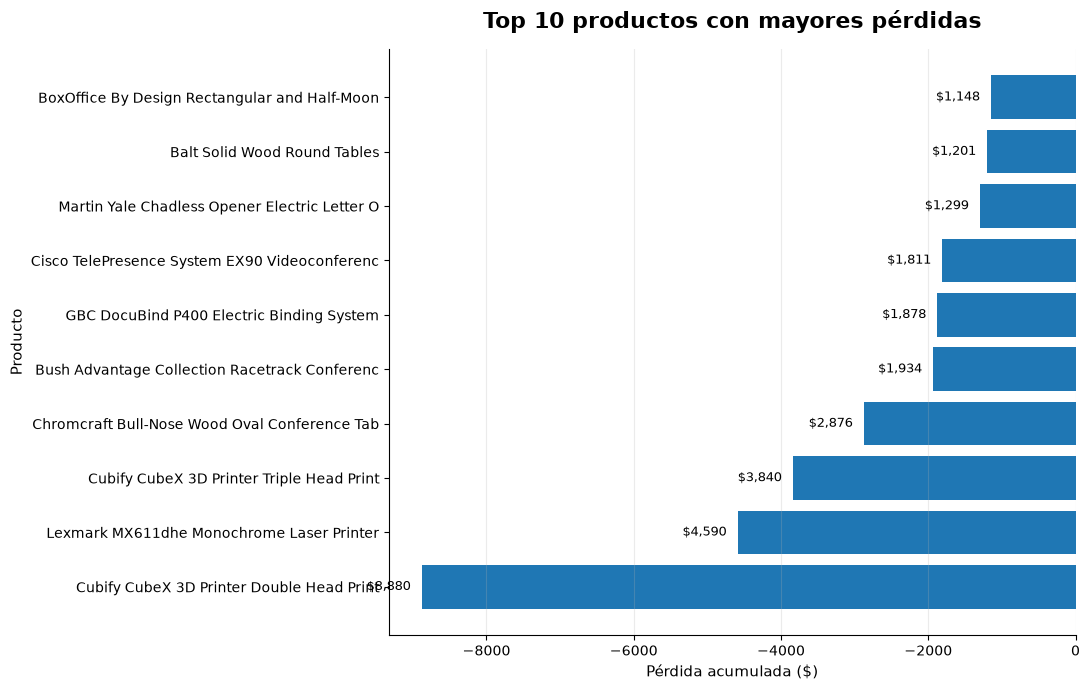

Gráfico guardado en: c:\Users\caesa\Python\Proyecto_Rentabilidad\images\top_productos_perdidas.png


In [259]:
import os
import matplotlib.pyplot as plt

# Crear la carpeta images en la raíz del proyecto
os.makedirs('../images', exist_ok=True)

# Tomar los 10 productos con mayor pérdida
top_loss_products = (
    product_profit_check[
        product_profit_check['Clasificacion'] == 'Con pérdida'
    ]
    .sort_values('Profit')
    .head(10)
    .copy()
)

# Crear etiquetas más cortas para mejorar la visualización
top_loss_products['Producto'] = (
    top_loss_products['Product Name']
    .str.replace(r'\s+', ' ', regex=True)
    .str.slice(0, 45)
)

# Crear gráfico
fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top_loss_products['Producto'],
    top_loss_products['Profit']
)

ax.set_title(
    'Top 10 productos con mayores pérdidas',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Pérdida acumulada ($)', fontsize=11)
ax.set_ylabel('Producto', fontsize=11)

# Mostrar valores al final de cada barra
for i, value in enumerate(top_loss_products['Profit']):
    ax.text(
        value - 150,
        i,
        f'${abs(value):,.0f}',
        va='center',
        ha='right',
        fontsize=9
    )

ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Guardar en la carpeta images de la raíz del proyecto
output_path = '../images/top_productos_perdidas.png'
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Gráfico guardado en: {os.path.abspath(output_path)}')

In [260]:
query_perdidas_categoria = """
SELECT
    "Category" AS categoria,
    COUNT(*) AS operaciones_con_perdida,
    SUM("Sales") AS ventas_con_perdida,
    SUM("Profit") AS perdida_acumulada,
    SUM("Quantity") AS unidades
FROM sales
WHERE "Profit" < -1e-9
GROUP BY "Category"
ORDER BY perdida_acumulada ASC;
"""

perdidas_categoria = pd.read_sql_query(
    query_perdidas_categoria,
    conn
)

perdidas_categoria

,categoria,operaciones_con_perdida,ventas_con_perdida,perdida_acumulada,unidades
0,Furniture,714,257885.5868,-60936.1090,2652.0
1,Office Supplies,886,91608.6750,-56615.2585,3425.0
2,Technology,271,119212.8930,-38579.9182,963.0


In [261]:
query_operaciones_perdida = """
SELECT
    COUNT(*) AS operaciones_con_perdida,
    SUM("Sales") AS ventas_asociadas,
    SUM("Profit") AS perdida_acumulada,
    SUM("Quantity") AS unidades
FROM sales
WHERE "Profit" < -1e-9;
"""

operaciones_perdida = pd.read_sql_query(
    query_operaciones_perdida,
    conn
)

operaciones_perdida

,operaciones_con_perdida,ventas_asociadas,perdida_acumulada,unidades
0,1871,468707.1548,-156131.2857,7040.0


In [262]:
query_perdidas_categoria_pct = """
SELECT
    "Category" AS categoria,
    COUNT(*) AS operaciones_con_perdida,
    SUM("Sales") AS ventas_asociadas,
    SUM("Profit") AS perdida_acumulada,
    SUM("Quantity") AS unidades
FROM sales
WHERE "Profit" < -1e-9
GROUP BY "Category"
ORDER BY perdida_acumulada ASC;
"""

perdidas_categoria_pct = pd.read_sql_query(
    query_perdidas_categoria_pct,
    conn
)

perdidas_categoria_pct["% operaciones"] = (
    perdidas_categoria_pct["operaciones_con_perdida"]
    / perdidas_categoria_pct["operaciones_con_perdida"].sum()
    * 100
)

perdidas_categoria_pct["% perdida"] = (
    perdidas_categoria_pct["perdida_acumulada"].abs()
    / perdidas_categoria_pct["perdida_acumulada"].abs().sum()
    * 100
)

perdidas_categoria_pct

,categoria,operaciones_con_perdida,ventas_asociadas,perdida_acumulada,unidades,% operaciones,% perdida
0,Furniture,714,257885.5868,-60936.1090,2652.0,38.161411,39.028763
1,Office Supplies,886,91608.6750,-56615.2585,3425.0,47.354356,36.261316
2,Technology,271,119212.8930,-38579.9182,963.0,14.484233,24.709922


In [263]:
df_sql.to_csv(
    '../data/ventas_limpias.csv',
    index=False
)

In [264]:
import os

os.path.exists('../data/ventas_limpias.csv')

True